# Analyse de sensibilité — terrainSA

Ce notebook repart du fichier `dataset_metamodel.csv` produit par les simulations `terrainSA`.

## Plan du notebook

### Partie I — Données et paramètres
- Chargement du dataset `terrainSA`.
- Reconstruction des 26 paramètres agricoles du plan SMT.

### Partie II — Analyses directes par ANOVA/Kruskal
- Analyse à un facteur avec R2 par paramètre.
- Analyse à deux facteurs avec R2 global, additif et interaction.
- Matrices de R2 pour les couples de paramètres.

### Partie III — Comparaison et sélection des métamodèles
- Comparaison ExtraTrees, XGBoost et Gaussian Process.
- Sélection automatique du meilleur modèle par sortie selon le Q2 test.

### Partie IV — Indices globaux via le meilleur métamodèle
- Indices de Sobol d'ordre 1 et d'ordre total.
- Valeurs de Shapley associées à chaque paramètre.

Les résultats sont écrits dans le dossier `analysis/terrainSA_results`.


In [1]:
# ============================================================
# 1. Imports et configuration
# ============================================================

from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    print("XGBoost indisponible, comparaison limitée à ExtraTrees et Gaussian Process :", exc)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA")
ANALYSIS_DIR = PROJECT_ROOT / "analysis"
OUTPUT_DIR = ANALYSIS_DIR / "terrainSA_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_CANDIDATES = [
    Path("/tmp/maelia_smt_terrainSA_xml/dataset_metamodel.csv"),
    PROJECT_ROOT / "data" / "dataset_metamodel_terrainSA.csv",
    ANALYSIS_DIR / "dataset_metamodel_terrainSA.csv",
    ANALYSIS_DIR / "dataset_metamodel.csv",
]

OUTPUT_COLS = ["N_lixi", "dCorg", "rdt"]
RANDOM_SEED = 42

# Réglages statistiques
N_QUANTILE_BINS = 4
MIN_GROUP_SIZE = 5
MIN_TOTAL_N = 30
TOP_TWO_FACTOR_PAIRS_TO_DISPLAY = 30

# Réglages métamodèle / Monte Carlo
TEST_SIZE = 0.25
N_TREES = 400
XGB_N_ESTIMATORS = 600
GP_MAX_TRAIN = 1500
SOBOL_N_MC = 2500
SHAPLEY_N_MC = 700
SHAPLEY_N_PERM = 64
SHAPLEY_N_INNER = 3

print("Dossier d'analyse :", ANALYSIS_DIR)
print("Dossier de sortie :", OUTPUT_DIR)


Dossier d'analyse : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis
Dossier de sortie : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results


In [3]:
# ============================================================
# 2. Chargement du dataset terrainSA
# ============================================================

DATASET_PATH = None
for candidate in DATASET_CANDIDATES:
    if candidate.exists():
        DATASET_PATH = candidate
        break

if DATASET_PATH is None:
    print("Aucun dataset terrainSA trouvé. Chemins testés :")
    for candidate in DATASET_CANDIDATES:
        print(" -", candidate)
    raise FileNotFoundError(
        "Exécuter d'abord le notebook de simulation terrainSA jusqu'à l'export "
        "de dataset_metamodel.csv, ou placer le fichier dans analysis/."
    )

df_raw = pd.read_csv(DATASET_PATH)
print("Dataset chargé :", DATASET_PATH)
print("Dimensions :", df_raw.shape)
display(df_raw.head())

missing_outputs = [col for col in OUTPUT_COLS if col not in df_raw.columns]
if missing_outputs:
    raise ValueError(f"Sorties absentes du dataset : {missing_outputs}")


Dataset chargé : /tmp/maelia_smt_terrainSA_xml/dataset_metamodel.csv
Dimensions : (10000, 33)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_23,feat_24,feat_25,Milieu (Climat),Milieu (Sol),N_lixi,dCorg,rdt,point_idx,parcelle
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.0,0,0,4.104,-131.560,3.905,0,beauce_5_sa_000
1,0.0,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.0,0,0,3.792,-116.816,3.580,1,beauce_5_sa_001
2,3.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,...,95.639825,86.928931,55.0,0,0,3.072,-174.028,4.305,2,beauce_5_sa_002
3,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.0,0,0,2.756,-139.558,3.995,3,beauce_5_sa_003
4,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,82.002372,55.000000,55.0,0,0,2.080,-179.400,4.495,4,beauce_5_sa_004


In [4]:
# ============================================================
# 3. Reconstruction des paramètres agricoles
# ============================================================

AGRI_FEATURES = [
    "n_ferti", "has_prepa", "nb_prepa", "prepa_1", "prepa_2",
    "nb_f1", "type_f1_1", "type_f1_2",
    "nb_f2", "type_f2_1", "type_f2_2",
    "nb_f3", "type_f3_1", "type_f3_2",
    "Jour_Semis", "Jours_av_PREPA", "Jours_semis_F1",
    "Jours_F1_F2", "Jours_F2_F3", "Jours_op_recolte",
    "Dose_F1_1", "Dose_F1_2", "Dose_F2_1", "Dose_F2_2", "Dose_F3_1", "Dose_F3_2",
]

AGRI_CATEGORICAL = [
    "n_ferti", "has_prepa", "nb_prepa", "prepa_1", "prepa_2",
    "nb_f1", "type_f1_1", "type_f1_2",
    "nb_f2", "type_f2_1", "type_f2_2",
    "nb_f3", "type_f3_1", "type_f3_2",
]
AGRI_CONTINUOUS = [c for c in AGRI_FEATURES if c not in AGRI_CATEGORICAL]

feat_cols = [f"feat_{i}" for i in range(26)]
if all(col in df_raw.columns for col in feat_cols):
    X_params = df_raw[feat_cols].copy()
    X_params.columns = AGRI_FEATURES
elif df_raw.shape[1] >= 26:
    X_params = df_raw.iloc[:, :26].copy()
    X_params.columns = AGRI_FEATURES
else:
    raise ValueError("Le dataset doit contenir 26 colonnes de paramètres agricoles.")

df = pd.concat([X_params, df_raw[OUTPUT_COLS]], axis=1)

if "point_idx" in df_raw.columns:
    df["point_idx"] = df_raw["point_idx"]
if "parcelle" in df_raw.columns:
    df["parcelle"] = df_raw["parcelle"]

# Les milieux sont volontairement constants dans terrainSA. On les conserve comme contexte,
# mais l'analyse de sensibilité porte sur les paramètres agricoles.
for col in ["Milieu (Climat)", "Milieu (Sol)", "zone", "sol_type", "zone_meteo"]:
    if col in df_raw.columns:
        df[col] = df_raw[col]

print("Paramètres agricoles :", len(AGRI_FEATURES))
print("Sorties :", OUTPUT_COLS)
display(df[AGRI_FEATURES + OUTPUT_COLS].head())


Paramètres agricoles : 26
Sorties : ['N_lixi', 'dCorg', 'rdt']


,n_ferti,has_prepa,nb_prepa,prepa_1,prepa_2,nb_f1,type_f1_1,type_f1_2,nb_f2,type_f2_1,...,Jours_op_recolte,Dose_F1_1,Dose_F1_2,Dose_F2_1,Dose_F2_2,Dose_F3_1,Dose_F3_2,N_lixi,dCorg,rdt
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.963033,54.539018,55.0,55.000000,55.000000,55.000000,55.0,4.104,-131.560,3.905
1,0.0,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,13.108975,55.000000,55.0,55.000000,55.000000,55.000000,55.0,3.792,-116.816,3.580
2,3.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,...,78.588034,19.551455,55.0,67.528051,95.639825,86.928931,55.0,3.072,-174.028,4.305
3,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,62.110062,87.615786,55.0,54.214918,55.000000,55.000000,55.0,2.756,-139.558,3.995
4,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,163.816420,27.300548,55.0,80.237982,82.002372,55.000000,55.0,2.080,-179.400,4.495


## Partie II.A — Analyse directe à un facteur

Pour chaque paramètre et chaque sortie :

- les variables continues sont discrétisées en quartiles ;
- les variables discrètes/catégorielles sont traitées comme facteurs ;
- le test utilisé est ANOVA si les hypothèses de normalité intra-groupe et d'homoscédasticité sont raisonnables, Kruskal sinon ;
- le `R2_parametre` est calculé comme la part de variance expliquée par les moyennes de groupes : `SS_between / SS_total`.


In [5]:
# ============================================================
# 4. Fonctions ANOVA/Kruskal à un facteur
# ============================================================

def factorize_for_tests(series, feature_name):
    s = series.copy()
    if feature_name in AGRI_CONTINUOUS:
        try:
            q = pd.qcut(s.astype(float), q=N_QUANTILE_BINS, duplicates="drop")
            return q.astype(str).replace("nan", np.nan)
        except Exception:
            return pd.Series(np.nan, index=s.index)
    return s.astype("object").where(s.notna(), "inactif").astype(str)


def grouped_arrays(y, groups):
    data = pd.DataFrame({"y": y, "group": groups}).dropna()
    counts = data["group"].value_counts()
    valid = counts[counts >= MIN_GROUP_SIZE].index
    data = data[data["group"].isin(valid)]
    arrays = [g["y"].to_numpy() for _, g in data.groupby("group", observed=True)]
    return data, arrays


def test_assumptions(arrays):
    if len(arrays) < 2:
        return False, np.nan, np.nan

    normal_pvals = []
    rng = np.random.default_rng(RANDOM_SEED)
    for arr in arrays:
        if len(arr) < 3:
            return False, np.nan, np.nan
        sample = arr
        if len(sample) > 500:
            sample = rng.choice(sample, size=500, replace=False)
        try:
            normal_pvals.append(stats.shapiro(sample).pvalue)
        except Exception:
            normal_pvals.append(0.0)

    try:
        levene_p = stats.levene(*arrays, center="median").pvalue
    except Exception:
        levene_p = 0.0

    normal_p = float(np.nanmin(normal_pvals))
    use_anova = normal_p > 0.01 and levene_p > 0.01
    return use_anova, normal_p, float(levene_p)


def grouped_r2(data):
    y = data["y"].to_numpy()
    if len(y) < 2:
        return np.nan
    ybar = np.mean(y)
    ss_total = np.sum((y - ybar) ** 2)
    if ss_total <= 0:
        return np.nan
    ss_between = 0.0
    for _, g in data.groupby("group", observed=True):
        ss_between += len(g) * (g["y"].mean() - ybar) ** 2
    return float(ss_between / ss_total)


def one_factor_analysis(df, output_col):
    rows = []
    y = df[output_col]
    for feature in AGRI_FEATURES:
        groups = factorize_for_tests(df[feature], feature)
        data, arrays = grouped_arrays(y, groups)
        if len(data) < MIN_TOTAL_N or len(arrays) < 2:
            rows.append({
                "sortie": output_col, "parametre": feature, "test": "non_testable",
                "p_value": np.nan, "R2_parametre": np.nan,
                "n": len(data), "n_groupes": len(arrays),
                "normalite_min_p": np.nan, "levene_p": np.nan,
            })
            continue

        use_anova, normal_p, levene_p = test_assumptions(arrays)
        if use_anova:
            stat = stats.f_oneway(*arrays)
            test_name = "ANOVA"
        else:
            stat = stats.kruskal(*arrays)
            test_name = "Kruskal"

        rows.append({
            "sortie": output_col,
            "parametre": feature,
            "test": test_name,
            "statistique": float(stat.statistic),
            "p_value": float(stat.pvalue),
            "R2_parametre": grouped_r2(data),
            "n": len(data),
            "n_groupes": len(arrays),
            "normalite_min_p": normal_p,
            "levene_p": levene_p,
        })
    return pd.DataFrame(rows)


In [6]:
# ============================================================
# 5. Exécution un facteur
# ============================================================

anova_1 = pd.concat([one_factor_analysis(df, y) for y in OUTPUT_COLS], ignore_index=True)
anova_1 = anova_1.sort_values(["sortie", "R2_parametre"], ascending=[True, False])
anova_1.to_csv(OUTPUT_DIR / "anova_kruskal_1facteur.csv", index=False)

anova_1_r2_sum = (
    anova_1.groupby("sortie", as_index=False)["R2_parametre"]
    .sum(min_count=1)
    .rename(columns={"R2_parametre": "somme_R2_1facteur"})
)
anova_1_r2_sum.to_csv(OUTPUT_DIR / "anova_1facteur_somme_R2.csv", index=False)

display(anova_1.groupby("sortie").head(12))
print("Somme des R2 - ANOVA/Kruskal un facteur :")
display(anova_1_r2_sum)
print("Écrit :", OUTPUT_DIR / "anova_kruskal_1facteur.csv")
print("Écrit :", OUTPUT_DIR / "anova_1facteur_somme_R2.csv")


,sortie,parametre,test,statistique,p_value,R2_parametre,n,n_groupes,normalite_min_p,levene_p
14,N_lixi,Jour_Semis,Kruskal,3384.867019,0.000000e+00,0.340547,10000,4,2.331189e-18,2.793740e-16
19,N_lixi,Jours_op_recolte,Kruskal,792.817979,1.562560e-171,0.081676,10000,4,2.054502e-12,3.794395e-49
15,N_lixi,Jours_av_PREPA,Kruskal,440.135736,2.665258e-96,0.041258,10000,3,3.286758e-11,3.590514e-10
16,N_lixi,Jours_semis_F1,Kruskal,395.224047,2.396874e-85,0.038522,10000,4,4.230727e-15,2.873746e-03
0,N_lixi,n_ferti,Kruskal,347.015823,6.604383e-75,0.034022,10000,4,7.060370e-18,6.027263e-22
1,N_lixi,has_prepa,Kruskal,282.602778,2.034299e-63,0.025252,10000,2,4.621006e-12,1.481621e-06
3,N_lixi,prepa_1,Kruskal,161.727224,7.769122e-35,0.014302,10000,4,5.396030e-10,2.712185e-05
20,N_lixi,Dose_F1_1,Kruskal,130.266846,4.737696e-28,0.012285,10000,4,1.266730e-13,4.507671e-10
5,N_lixi,nb_f1,Kruskal,111.974023,4.125499e-24,0.010511,10000,4,2.271321e-11,1.588847e-07
2,N_lixi,nb_prepa,Kruskal,91.427692,1.157453e-21,0.008204,10000,2,1.622320e-09,2.869820e-04


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/anova_kruskal_1facteur.csv


## Partie II.B — Analyse directe à deux facteurs

Pour chaque paire de paramètres, on ajuste deux modèles linéaires sur facteurs discrétisés :

- modèle additif : `A + B` ;
- modèle saturé par cellules : `A:B`, qui contient les effets principaux et leur interaction.

On rapporte :

- `R2_A` et `R2_B` : R2 des analyses à un facteur ;
- `R2_additif` : variance expliquée par les deux facteurs sans interaction ;
- `R2_interaction` : gain de R2 apporté par les cellules `A:B` ;
- `R2_global` : R2 du modèle à deux facteurs complet.

Si les distributions sont très non normales, cette approche doit être lue comme une ANOVA descriptive sur groupes, pas comme une preuve paramétrique stricte.


In [7]:
# ============================================================
# 6. Fonctions deux facteurs
# ============================================================

def ols_r2_and_pvalue(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[ok]
    X = X[ok]
    n = len(y)
    if n < MIN_TOTAL_N:
        return np.nan, np.nan, np.nan, np.nan

    X_design = np.column_stack([np.ones(n), X])
    beta, *_ = np.linalg.lstsq(X_design, y, rcond=None)
    yhat = X_design @ beta
    sse = np.sum((y - yhat) ** 2)
    sst = np.sum((y - np.mean(y)) ** 2)
    if sst <= 0:
        return np.nan, np.nan, np.nan, np.nan

    rank = np.linalg.matrix_rank(X_design)
    df_model = rank - 1
    df_resid = n - rank
    r2 = 1.0 - sse / sst
    if df_model <= 0 or df_resid <= 0 or sse <= 0:
        pval = np.nan
        fstat = np.nan
    else:
        fstat = ((sst - sse) / df_model) / (sse / df_resid)
        pval = float(stats.f.sf(fstat, df_model, df_resid))
    return float(r2), pval, float(df_model), float(df_resid)


def two_factor_analysis(df, output_col):
    one_r2 = (
        anova_1[anova_1["sortie"] == output_col]
        .set_index("parametre")["R2_parametre"]
        .to_dict()
    )

    rows = []
    y = df[output_col]
    for a, b in itertools.combinations(AGRI_FEATURES, 2):
        fa = factorize_for_tests(df[a], a)
        fb = factorize_for_tests(df[b], b)
        data = pd.DataFrame({"y": y, "A": fa, "B": fb}).dropna()

        if len(data) < MIN_TOTAL_N:
            continue

        data["cell"] = data["A"].astype(str) + " × " + data["B"].astype(str)
        cell_counts = data["cell"].value_counts()
        valid_cells = cell_counts[cell_counts >= MIN_GROUP_SIZE].index
        data = data[data["cell"].isin(valid_cells)].copy()
        if data["A"].nunique() < 2 or data["B"].nunique() < 2 or data["cell"].nunique() < 2:
            continue

        X_add = pd.get_dummies(data[["A", "B"]].astype(str), drop_first=True)
        X_full = pd.get_dummies(data["cell"].astype(str), drop_first=True)

        r2_add, p_add, _, _ = ols_r2_and_pvalue(data["y"], X_add)
        r2_full, p_full, df_model, df_resid = ols_r2_and_pvalue(data["y"], X_full)

        rows.append({
            "sortie": output_col,
            "parametre_A": a,
            "parametre_B": b,
            "R2_A": one_r2.get(a, np.nan),
            "R2_B": one_r2.get(b, np.nan),
            "R2_additif": r2_add,
            "R2_interaction": r2_full - r2_add if pd.notna(r2_full) and pd.notna(r2_add) else np.nan,
            "R2_global": r2_full,
            "p_value_additif": p_add,
            "p_value_global": p_full,
            "n": len(data),
            "n_A": data["A"].nunique(),
            "n_B": data["B"].nunique(),
            "n_cellules": data["cell"].nunique(),
            "df_model_global": df_model,
            "df_resid_global": df_resid,
        })

    return pd.DataFrame(rows)


In [8]:
# ============================================================
# 7. Exécution deux facteurs
# ============================================================

anova_2 = pd.concat([two_factor_analysis(df, y) for y in OUTPUT_COLS], ignore_index=True)
anova_2 = anova_2.sort_values(["sortie", "R2_global"], ascending=[True, False])
anova_2.to_csv(OUTPUT_DIR / "anova_2facteurs.csv", index=False)

anova_2_r2_sum = (
    anova_2.groupby("sortie", as_index=False)
    .agg(
        somme_R2_additif=("R2_additif", "sum"),
        somme_R2_interaction=("R2_interaction", "sum"),
        somme_R2_global=("R2_global", "sum"),
    )
)
anova_2_r2_sum.to_csv(OUTPUT_DIR / "anova_2facteurs_somme_R2.csv", index=False)

def build_two_factor_matrix(anova_2, output_col, value_col="R2_global"):
    matrix = pd.DataFrame(np.nan, index=AGRI_FEATURES, columns=AGRI_FEATURES, dtype=float)
    sub = anova_2[anova_2["sortie"] == output_col]
    for row in sub.itertuples(index=False):
        a = row.parametre_A
        b = row.parametre_B
        value = getattr(row, value_col)
        matrix.loc[a, b] = value
        matrix.loc[b, a] = value
    np.fill_diagonal(matrix.values, 0.0)
    return matrix

anova_2_matrices = {}
for output in OUTPUT_COLS:
    matrix_global = build_two_factor_matrix(anova_2, output, "R2_global")
    matrix_interaction = build_two_factor_matrix(anova_2, output, "R2_interaction")
    anova_2_matrices[(output, "R2_global")] = matrix_global
    anova_2_matrices[(output, "R2_interaction")] = matrix_interaction
    matrix_global.to_csv(OUTPUT_DIR / f"anova_2facteurs_matrice_R2_global_{output}.csv")
    matrix_interaction.to_csv(OUTPUT_DIR / f"anova_2facteurs_matrice_R2_interaction_{output}.csv")

display(anova_2.groupby("sortie").head(TOP_TWO_FACTOR_PAIRS_TO_DISPLAY))
print("Somme des R2 - ANOVA deux facteurs :")
display(anova_2_r2_sum)

for output in OUTPUT_COLS:
    print(f"Matrice ANOVA deux facteurs - R2_global - {output}")
    display(anova_2_matrices[(output, "R2_global")].round(3))
    print(f"Matrice ANOVA deux facteurs - R2_interaction - {output}")
    display(anova_2_matrices[(output, "R2_interaction")].round(3))

print("Écrit :", OUTPUT_DIR / "anova_2facteurs.csv")
print("Écrit :", OUTPUT_DIR / "anova_2facteurs_somme_R2.csv")


,sortie,parametre_A,parametre_B,R2_A,R2_B,R2_additif,R2_interaction,R2_global,p_value_additif,p_value_global,n,n_A,n_B,n_cellules,df_model_global,df_resid_global
263,N_lixi,Jour_Semis,Jours_op_recolte,0.340547,0.081676,0.420901,0.007302,0.428203,0.0,0.0,10000,4,4,16,15.0,9984.0
13,N_lixi,n_ferti,Jour_Semis,0.034022,0.340547,0.374732,0.029411,0.404143,0.0,0.0,10000,4,4,16,15.0,9984.0
260,N_lixi,Jour_Semis,Jours_semis_F1,0.340547,0.038522,0.377771,0.021387,0.399158,0.0,0.0,10000,4,4,16,15.0,9984.0
259,N_lixi,Jour_Semis,Jours_av_PREPA,0.340547,0.041258,0.381352,0.000999,0.382352,0.0,0.0,10000,4,3,12,11.0,9988.0
37,N_lixi,has_prepa,Jour_Semis,0.025252,0.340547,0.368878,0.000471,0.369349,0.0,0.0,10000,2,4,8,7.0,9992.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933,rdt,Jours_semis_F1,Dose_F1_1,0.344160,0.315037,0.431072,0.108628,0.539700,0.0,0.0,10000,4,4,16,15.0,9984.0
775,rdt,nb_f1,Jours_semis_F1,0.233127,0.344160,0.401759,0.107733,0.509493,0.0,0.0,10000,4,4,16,15.0,9984.0
932,rdt,Jours_semis_F1,Jours_op_recolte,0.344160,0.042873,0.392839,0.097708,0.490547,0.0,0.0,10000,4,4,16,15.0,9984.0
779,rdt,nb_f1,Dose_F1_1,0.233127,0.315037,0.371739,0.107906,0.479646,0.0,0.0,10000,4,4,16,15.0,9984.0


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/anova_2facteurs.csv


## Partie III — Comparaison et sélection des métamodèles

Le plan SMT n'est pas un plan de Saltelli. Les indices Sobol et Shapley seront donc estimés à partir d'un métamodèle.

On compare ici trois familles :

- `ExtraTreesRegressor`, robuste et rapide sur variables mixtes ;
- `XGBoost`, souvent très performant pour des relations non linéaires tabulaires ;
- `GaussianProcessRegressor`, utile comme référence probabiliste mais entraîné sur un sous-échantillon car son coût croît fortement avec le nombre d'observations.

Le meilleur modèle est sélectionné séparément pour chaque sortie selon le `Q2_test`, c'est-à-dire le R2 prédictif sur l'échantillon de test. Les sections Sobol et Shapley utilisent ensuite automatiquement ce meilleur modèle.


In [37]:
# ============================================================
# 8. Comparaison ExtraTrees / XGBoost / Gaussian Process
# ============================================================

X = df[AGRI_FEATURES].copy()
for col in AGRI_CATEGORICAL:
    X[col] = X[col].astype("object").where(X[col].notna(), "inactif").astype(str)
for col in AGRI_CONTINUOUS:
    X[col] = pd.to_numeric(X[col], errors="coerce")

def make_preprocess():
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="inactif")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    continuous_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    return ColumnTransformer([
        ("cat", categorical_transformer, AGRI_CATEGORICAL),
        ("num", continuous_transformer, AGRI_CONTINUOUS),
    ])

def make_extra_trees(seed=RANDOM_SEED):
    return Pipeline([
        ("preprocess", make_preprocess()),
        ("model", ExtraTreesRegressor(
            n_estimators=N_TREES,
            random_state=seed,
            n_jobs=-1,
            min_samples_leaf=2,
        )),
    ])

def make_xgboost(seed=RANDOM_SEED):
    if not XGBOOST_AVAILABLE:
        return None
    return Pipeline([
        ("preprocess", make_preprocess()),
        ("model", XGBRegressor(
            n_estimators=XGB_N_ESTIMATORS,
            max_depth=4,
            learning_rate=0.035,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=seed,
            n_jobs=-1,
            reg_lambda=1.0,
        )),
    ])

def make_gaussian_process(seed=RANDOM_SEED):
    kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * Matern(nu=2.5) + WhiteKernel(noise_level=1e-4)
    return Pipeline([
        ("preprocess", make_preprocess()),
        ("model", GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            alpha=1e-6,
            random_state=seed,
            optimizer=None,
        )),
    ])

def candidate_models(seed=RANDOM_SEED):
    candidates = {
        "ExtraTrees": make_extra_trees(seed),
        "GaussianProcess": make_gaussian_process(seed),
    }
    xgb = make_xgboost(seed)
    if xgb is not None:
        candidates["XGBoost"] = xgb
    return candidates

models = {}
best_model_names = {}
fitted_candidates = {}
score_rows = []

X_train, X_test = train_test_split(X, test_size=TEST_SIZE, random_state=RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

for output in OUTPUT_COLS:
    y = df[output].astype(float)
    y_train = y.loc[X_train.index]
    y_test = y.loc[X_test.index]

    for model_name, model in candidate_models(RANDOM_SEED + OUTPUT_COLS.index(output)).items():
        if model_name == "GaussianProcess" and len(X_train) > GP_MAX_TRAIN:
            gp_idx = rng.choice(X_train.index.to_numpy(), size=GP_MAX_TRAIN, replace=False)
            X_fit = X_train.loc[gp_idx]
            y_fit = y.loc[gp_idx]
        else:
            X_fit = X_train
            y_fit = y_train

        try:
            model.fit(X_fit, y_fit)
            pred_train = model.predict(X_fit)
            pred_test = model.predict(X_test)
            q2_test = r2_score(y_test, pred_test)
            fitted_candidates[(output, model_name)] = model
            score_rows.append({
                "sortie": output,
                "metamodele": model_name,
                "Q2_test": q2_test,
                "R2_train_effectif": r2_score(y_fit, pred_train),
                "MAE_test": mean_absolute_error(y_test, pred_test),
                "RMSE_test": mean_squared_error(y_test, pred_test) ** 0.5,
                "n_train_total": len(X_train),
                "n_train_effectif": len(X_fit),
                "n_test": len(X_test),
                "statut": "ok",
            })
        except Exception as exc:
            score_rows.append({
                "sortie": output,
                "metamodele": model_name,
                "Q2_test": np.nan,
                "R2_train_effectif": np.nan,
                "MAE_test": np.nan,
                "RMSE_test": np.nan,
                "n_train_total": len(X_train),
                "n_train_effectif": len(X_fit),
                "n_test": len(X_test),
                "statut": f"erreur: {exc}",
            })

scores_df = pd.DataFrame(score_rows)
scores_df = scores_df.sort_values(["sortie", "Q2_test"], ascending=[True, False])
scores_df.to_csv(OUTPUT_DIR / "metamodel_comparison.csv", index=False)

best_rows = []
for output in OUTPUT_COLS:
    valid = scores_df[(scores_df["sortie"] == output) & scores_df["Q2_test"].notna()]
    if valid.empty:
        raise RuntimeError(f"Aucun métamodèle valide pour {output}")
    best = valid.sort_values("Q2_test", ascending=False).iloc[0]
    best_name = best["metamodele"]
    best_model_names[output] = best_name
    models[output] = fitted_candidates[(output, best_name)]
    best_rows.append(best)

best_models_df = pd.DataFrame(best_rows).reset_index(drop=True)
best_models_df.to_csv(OUTPUT_DIR / "metamodel_best_models.csv", index=False)

print("Comparaison des métamodèles — Q2 test par sortie :")
display(scores_df)

print("Meilleur métamodèle sélectionné par sortie :")
display(best_models_df[["sortie", "metamodele", "Q2_test", "MAE_test", "RMSE_test", "n_train_effectif", "n_test"]])

q2_matrix = scores_df.pivot(index="sortie", columns="metamodele", values="Q2_test")
display(q2_matrix.round(4))

print("Écrit :", OUTPUT_DIR / "metamodel_comparison.csv")
print("Écrit :", OUTPUT_DIR / "metamodel_best_models.csv")


Comparaison des métamodèles — Q2 test par sortie :


,sortie,metamodele,Q2_test,R2_train_effectif,MAE_test,RMSE_test,n_train_total,n_train_effectif,n_test,statut
0,N_lixi,ExtraTrees,0.863318,0.995782,0.195593,0.282084,7500,7500,2500,ok
2,N_lixi,XGBoost,0.854751,0.916076,0.219354,0.290790,7500,7500,2500,ok
1,N_lixi,GaussianProcess,0.384789,0.999977,0.453007,0.598458,7500,1500,2500,ok
3,dCorg,ExtraTrees,0.990684,0.999694,5.207281,8.952551,7500,7500,2500,ok
5,dCorg,XGBoost,0.986825,0.992861,7.404486,10.646706,7500,7500,2500,ok
4,dCorg,GaussianProcess,0.494290,1.000000,50.025466,65.961404,7500,1500,2500,ok
6,rdt,ExtraTrees,0.959470,0.998491,0.044952,0.070644,7500,7500,2500,ok
8,rdt,XGBoost,0.930901,0.959330,0.063779,0.092241,7500,7500,2500,ok
7,rdt,GaussianProcess,0.615527,0.999978,0.165043,0.217580,7500,1500,2500,ok


Meilleur métamodèle sélectionné par sortie :


,sortie,metamodele,Q2_test,MAE_test,RMSE_test,n_train_effectif,n_test
0,N_lixi,ExtraTrees,0.863318,0.195593,0.282084,7500,2500
1,dCorg,ExtraTrees,0.990684,5.207281,8.952551,7500,2500
2,rdt,ExtraTrees,0.959470,0.044952,0.070644,7500,2500


metamodele,ExtraTrees,GaussianProcess,XGBoost
sortie,,,
N_lixi,0.8633,0.3848,0.8548
dCorg,0.9907,0.4943,0.9868
rdt,0.9595,0.6155,0.9309


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/metamodel_comparison.csv
Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/metamodel_best_models.csv


In [10]:
# ============================================================
# 9. Indices de Sobol ordre 1 et total, via pick-freeze
# ============================================================

def empirical_sample(X_ref, n, rng):
    idx = rng.integers(0, len(X_ref), size=n)
    return X_ref.iloc[idx].reset_index(drop=True).copy()


def estimate_sobol(model, X_ref, features, n_mc=SOBOL_N_MC, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    A = empirical_sample(X_ref, n_mc, rng)
    B = empirical_sample(X_ref, n_mc, rng)

    yA = model.predict(A)
    yB = model.predict(B)
    variance = np.var(np.concatenate([yA, yB]), ddof=1)
    if variance <= 0:
        return pd.DataFrame()

    rows = []
    for feature in features:
        AB = A.copy()
        AB[feature] = B[feature].to_numpy()
        yAB = model.predict(AB)

        s1 = np.mean(yB * (yAB - yA)) / variance
        st = 0.5 * np.mean((yA - yAB) ** 2) / variance

        rows.append({
            "parametre": feature,
            "Sobol_S1": float(s1),
            "Sobol_ST": float(st),
        })
    return pd.DataFrame(rows)


sobol_rows = []
for output, model in models.items():
    tmp = estimate_sobol(model, X, AGRI_FEATURES, seed=RANDOM_SEED + OUTPUT_COLS.index(output))
    tmp.insert(0, "sortie", output)
    tmp.insert(1, "metamodele", best_model_names.get(output, ""))
    sobol_rows.append(tmp)

sobol_df = pd.concat(sobol_rows, ignore_index=True)
sobol_df = sobol_df.sort_values(["sortie", "Sobol_ST"], ascending=[True, False])
sobol_df.to_csv(OUTPUT_DIR / "sobol_indices.csv", index=False)

display(sobol_df.groupby("sortie").head(15))
print("Écrit :", OUTPUT_DIR / "sobol_indices.csv")


,sortie,parametre,Sobol_S1,Sobol_ST
14,N_lixi,Jour_Semis,0.590051,0.519091
19,N_lixi,Jours_op_recolte,0.184668,0.301893
0,N_lixi,n_ferti,0.041645,0.179294
16,N_lixi,Jours_semis_F1,0.111676,0.158568
1,N_lixi,has_prepa,-0.007463,0.046579
15,N_lixi,Jours_av_PREPA,-0.007802,0.023764
17,N_lixi,Jours_F1_F2,0.014343,0.006686
7,N_lixi,type_f1_2,0.022922,0.002818
5,N_lixi,nb_f1,0.010921,0.002731
18,N_lixi,Jours_F2_F3,-0.004490,0.002580


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/sobol_indices.csv


In [11]:
# ============================================================
# 10. Valeurs de Shapley de variance, via métamodèle
# ============================================================

def estimate_shapley_effects(
    model,
    X_ref,
    features,
    n_mc=SHAPLEY_N_MC,
    n_perm=SHAPLEY_N_PERM,
    n_inner=SHAPLEY_N_INNER,
    seed=RANDOM_SEED,
):
    rng = np.random.default_rng(seed)
    A = empirical_sample(X_ref, n_mc, rng)
    p = len(features)
    full_set = frozenset(features)
    cache = {}

    def coalition_value(S):
        S = frozenset(S)
        if len(S) == 0:
            return 0.0
        if S in cache:
            return cache[S]

        if S == full_set:
            value = float(np.var(model.predict(A), ddof=1))
            cache[S] = value
            return value

        pred_sum = np.zeros(n_mc)
        for _ in range(n_inner):
            X_mix = empirical_sample(X_ref, n_mc, rng)
            for col in S:
                X_mix[col] = A[col].to_numpy()
            pred_sum += model.predict(X_mix)
        conditional_mean = pred_sum / n_inner
        value = float(np.var(conditional_mean, ddof=1))
        cache[S] = value
        return value

    phi = {feature: 0.0 for feature in features}
    for _ in range(n_perm):
        perm = list(features)
        rng.shuffle(perm)
        S = set()
        prev = coalition_value(S)
        for feature in perm:
            S.add(feature)
            cur = coalition_value(S)
            phi[feature] += cur - prev
            prev = cur

    total_value = coalition_value(full_set)
    rows = []
    for feature in features:
        raw = phi[feature] / n_perm
        rows.append({
            "parametre": feature,
            "Shapley_variance": float(raw),
            "Shapley_normalise": float(raw / total_value) if total_value > 0 else np.nan,
            "variance_modele": total_value,
            "n_permutations": n_perm,
            "n_mc": n_mc,
        })
    return pd.DataFrame(rows)


shapley_rows = []
for output, model in models.items():
    print(f"Shapley — {output} ...")
    tmp = estimate_shapley_effects(
        model,
        X,
        AGRI_FEATURES,
        seed=RANDOM_SEED + 100 + OUTPUT_COLS.index(output),
    )
    tmp.insert(0, "sortie", output)
    tmp.insert(1, "metamodele", best_model_names.get(output, ""))
    shapley_rows.append(tmp)

shapley_df = pd.concat(shapley_rows, ignore_index=True)
shapley_df = shapley_df.sort_values(["sortie", "Shapley_normalise"], ascending=[True, False])
shapley_df.to_csv(OUTPUT_DIR / "shapley_values.csv", index=False)

display(shapley_df.groupby("sortie").head(15))
print("Écrit :", OUTPUT_DIR / "shapley_values.csv")


Shapley — N_lixi ...
Shapley — dCorg ...
Shapley — rdt ...


,sortie,parametre,Shapley_variance,Shapley_normalise,variance_modele,n_permutations,n_mc
14,N_lixi,Jour_Semis,0.155724,0.317187,0.490955,64,700
19,N_lixi,Jours_op_recolte,0.071908,0.146466,0.490955,64,700
0,N_lixi,n_ferti,0.043946,0.089511,0.490955,64,700
16,N_lixi,Jours_semis_F1,0.034713,0.070705,0.490955,64,700
1,N_lixi,has_prepa,0.027824,0.056674,0.490955,64,700
15,N_lixi,Jours_av_PREPA,0.016578,0.033767,0.490955,64,700
8,N_lixi,nb_f2,0.013948,0.028409,0.490955,64,700
23,N_lixi,Dose_F2_2,0.011938,0.024315,0.490955,64,700
22,N_lixi,Dose_F2_1,0.011014,0.022433,0.490955,64,700
21,N_lixi,Dose_F1_2,0.010098,0.020569,0.490955,64,700


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/shapley_values.csv


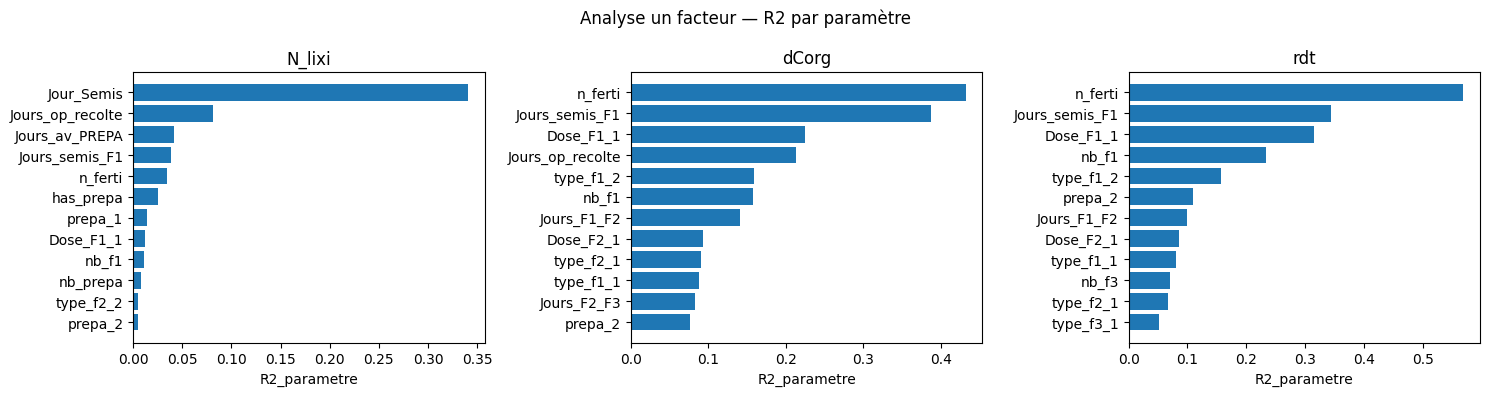

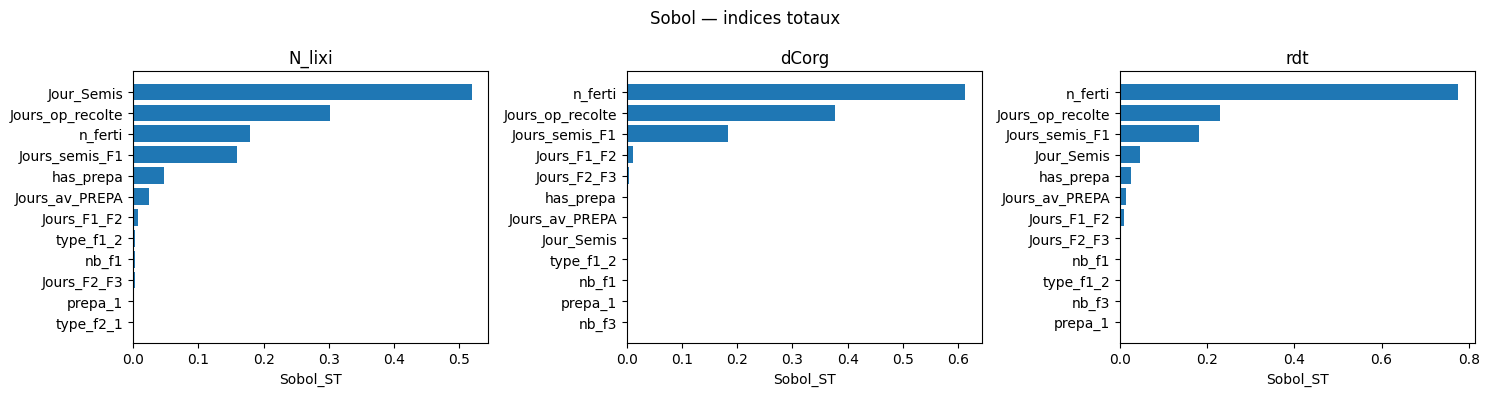

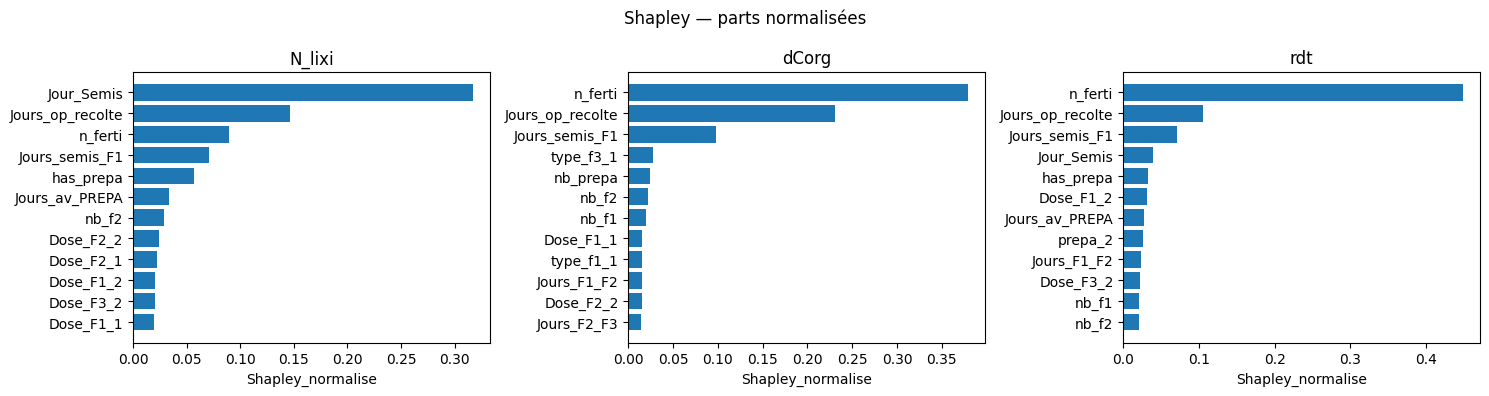

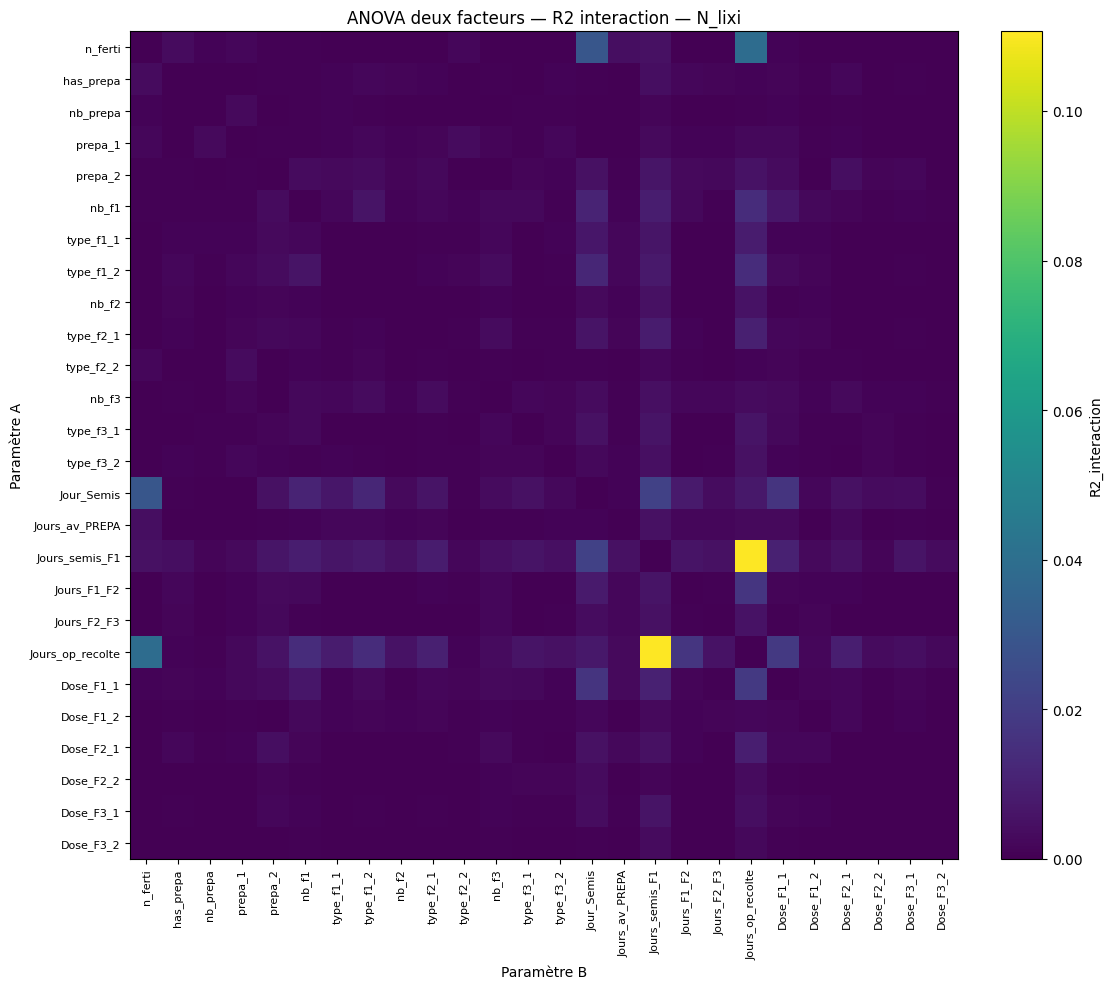

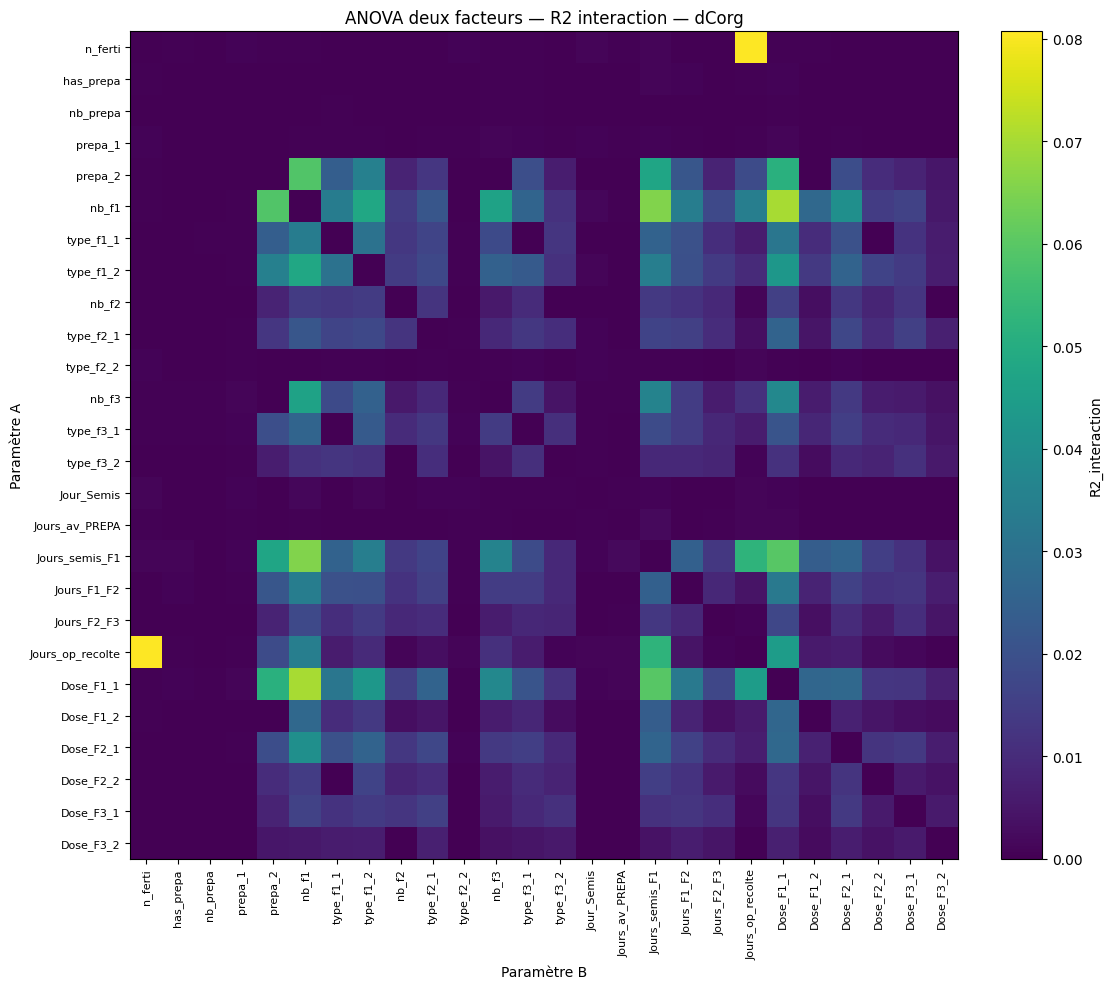

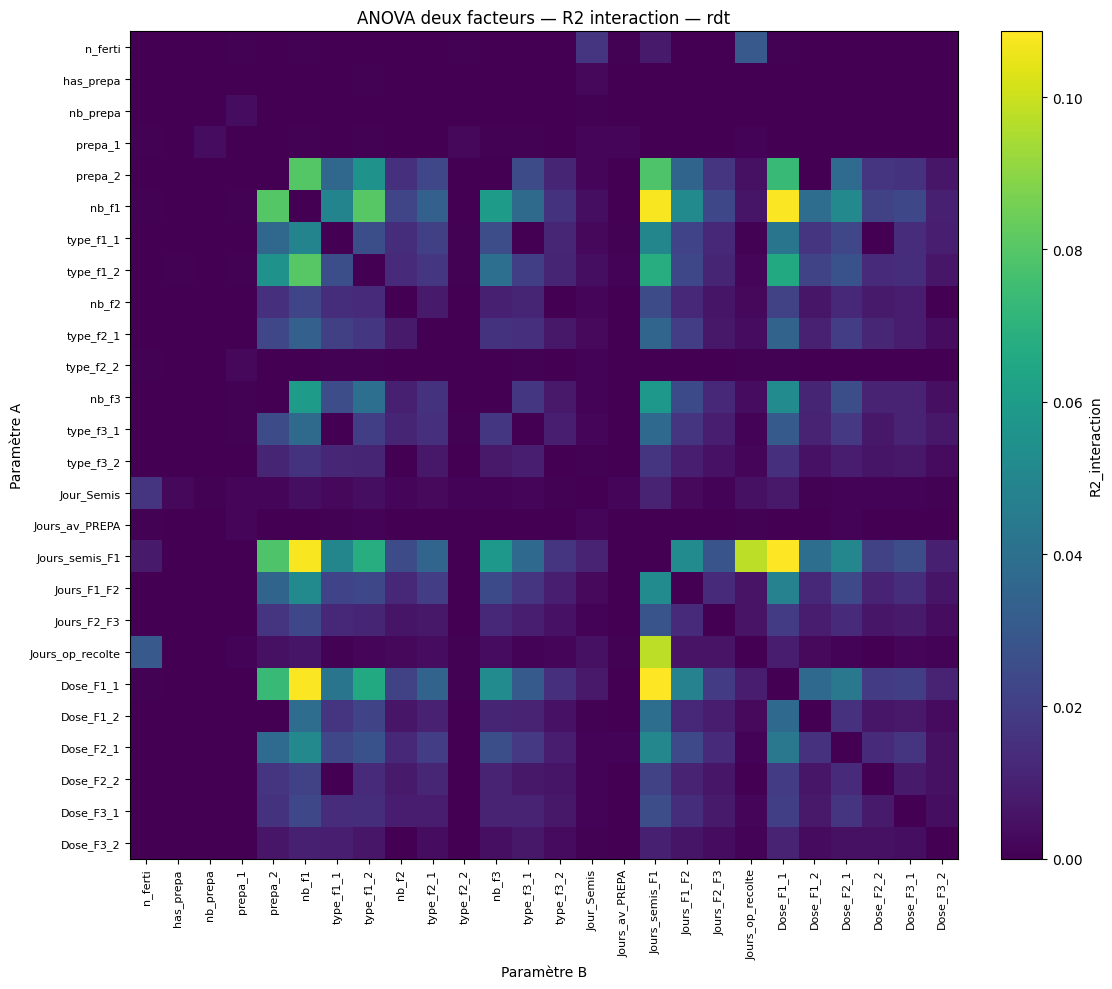

Figures écrites dans : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results


In [36]:
# ============================================================
# 11. Figures de synthèse
# ============================================================

def plot_top(df_plot, value_col, title, filename, top_n=12):
    fig, axes = plt.subplots(1, len(OUTPUT_COLS), figsize=(5 * len(OUTPUT_COLS), 4), sharex=False)
    if len(OUTPUT_COLS) == 1:
        axes = [axes]
    for ax, output in zip(axes, OUTPUT_COLS):
        sub = (
            df_plot[df_plot["sortie"] == output]
            .sort_values(value_col, ascending=False)
            .head(top_n)
            .iloc[::-1]
        )
        ax.barh(sub["parametre"], sub[value_col])
        ax.set_title(output)
        ax.set_xlabel(value_col)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()

def plot_anova_matrix_heatmap(output, value_col, title, filename, vmax=None):
    matrix = anova_2_matrices[(output, value_col)].copy()
    matrix = matrix.reindex(index=AGRI_FEATURES, columns=AGRI_FEATURES)
    masked = np.ma.masked_invalid(matrix.to_numpy(dtype=float))

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(masked, cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(AGRI_FEATURES)))
    ax.set_yticks(np.arange(len(AGRI_FEATURES)))
    ax.set_xticklabels(AGRI_FEATURES, rotation=90, fontsize=8)
    ax.set_yticklabels(AGRI_FEATURES, fontsize=8)
    ax.set_xlabel("Paramètre B")
    ax.set_ylabel("Paramètre A")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(value_col)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()

def plot_all_anova_heatmaps():
    for output in OUTPUT_COLS:
        plot_anova_matrix_heatmap(
            output=output,
            value_col="R2_interaction",
            title=f"ANOVA deux facteurs — R2 interaction — {output}",
            filename=f"heatmap_anova_2facteurs_R2_interaction_{output}.png",
            vmax=None,
        )

plot_top(anova_1, "R2_parametre", "Analyse un facteur — R2 par paramètre", "anova_1facteur_top.png")
plot_top(sobol_df, "Sobol_ST", "Sobol — indices totaux", "sobol_total_top.png")
plot_top(shapley_df, "Shapley_normalise", "Shapley — parts normalisées", "shapley_top.png")
plot_all_anova_heatmaps()

print("Figures écrites dans :", OUTPUT_DIR)


## À lire avant interprétation

- `terrainSA` fixe volontairement le sol et le climat ; les indices portent donc sur les opérations techniques uniquement.
- Les tests ANOVA/Kruskal à un facteur sont directs et descriptifs sur les sorties MAELIA.
- Les analyses à deux facteurs utilisent des facteurs discrétisés et rapportent surtout les R2 globaux et d'interaction.
- Les métamodèles sont comparés par `Q2_test`; Sobol et Shapley utilisent le meilleur modèle par sortie.
- Le Gaussian Process est entraîné sur un sous-échantillon (`GP_MAX_TRAIN`) pour rester calculable.
- Les indices Sobol et Shapley sont estimés via un métamodèle, parce que le DOE SMT/ADSG n'est pas un plan Saltelli.
- Si le meilleur `Q2_test` reste faible pour une sortie, les indices Sobol/Shapley de cette sortie doivent être considérés comme exploratoires.
